# Trust Dynamics Simulation

Model: \n$T_{t+1} = \lambda T_t + (1-\lambda)\hat{T}_t - \delta \cdot \mathrm{Override}_t$


In [1]:
import numpy as np
import matplotlib.pyplot as plt


Matplotlib is building the font cache; this may take a moment.


In [2]:
# Parameters
w1, w2, w3 = 0.30, 0.45, 0.25
lam = 0.8
delta = 0.06
T0 = 0.76
steps = 24


In [3]:
# Synthetic interaction stream (replace with real pilot measurements)
rng = np.random.default_rng(42)
transparency = np.clip(rng.normal(0.72, 0.08, steps), 0, 1)
accuracy = np.clip(rng.normal(0.80, 0.07, steps), 0, 1)
cultural_fit = np.clip(rng.normal(0.66, 0.10, steps), 0, 1)
overrides = (rng.random(steps) < 0.22).astype(int)
T_hat = w1*transparency + w2*accuracy + w3*cultural_fit


In [4]:
T = np.zeros(steps+1)
T[0] = T0
for t in range(steps):
    T[t+1] = lam*T[t] + (1-lam)*T_hat[t] - delta*overrides[t]

T = np.clip(T, 0, 1)


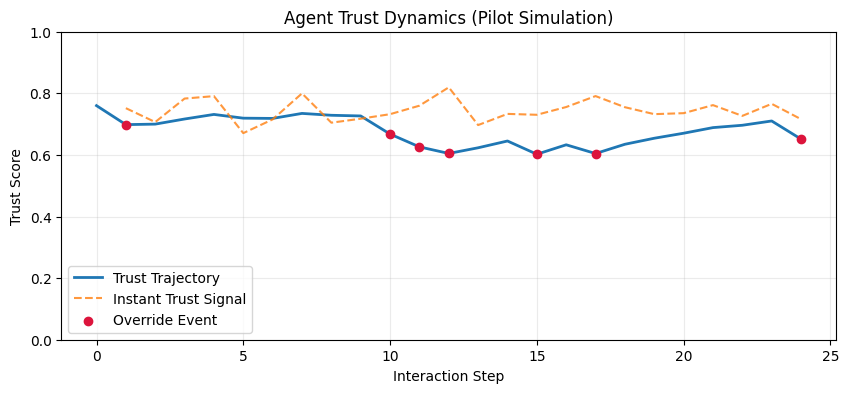

In [5]:
plt.figure(figsize=(10,4))
plt.plot(T, label='Trust Trajectory', linewidth=2)
plt.plot(np.arange(1, steps+1), T_hat, '--', label='Instant Trust Signal', alpha=0.8)
override_idx = np.where(overrides==1)[0] + 1
plt.scatter(override_idx, T[override_idx], color='crimson', label='Override Event', zorder=3)
plt.ylim(0,1)
plt.xlabel('Interaction Step')
plt.ylabel('Trust Score')
plt.title('Agent Trust Dynamics (Pilot Simulation)')
plt.grid(alpha=0.25)
plt.legend()
plt.show()


In [6]:
print(f'Initial trust: {T[0]:.3f}')
print(f'Final trust:   {T[-1]:.3f}')
print(f'Override rate: {overrides.mean():.2%}')
print(f'Mean T_hat:    {T_hat.mean():.3f}')


Initial trust: 0.760
Final trust:   0.651
Override rate: 29.17%
Mean T_hat:    0.744
